In [155]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment_28'

data_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

data_df['operator'] = data_df['operator'].astype(int)

data_df['beamforming'] = data_df['operator'] != 1

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['pca'] = data_df['use_pca'].apply(lambda x: 'With PCA' if x == 1 else 'Without PCA')

result_df = data_df
result_df['complexity'] = result_df['complexity'] / 1000

result_df.sort_values('use_pca', ascending=True, inplace=True)



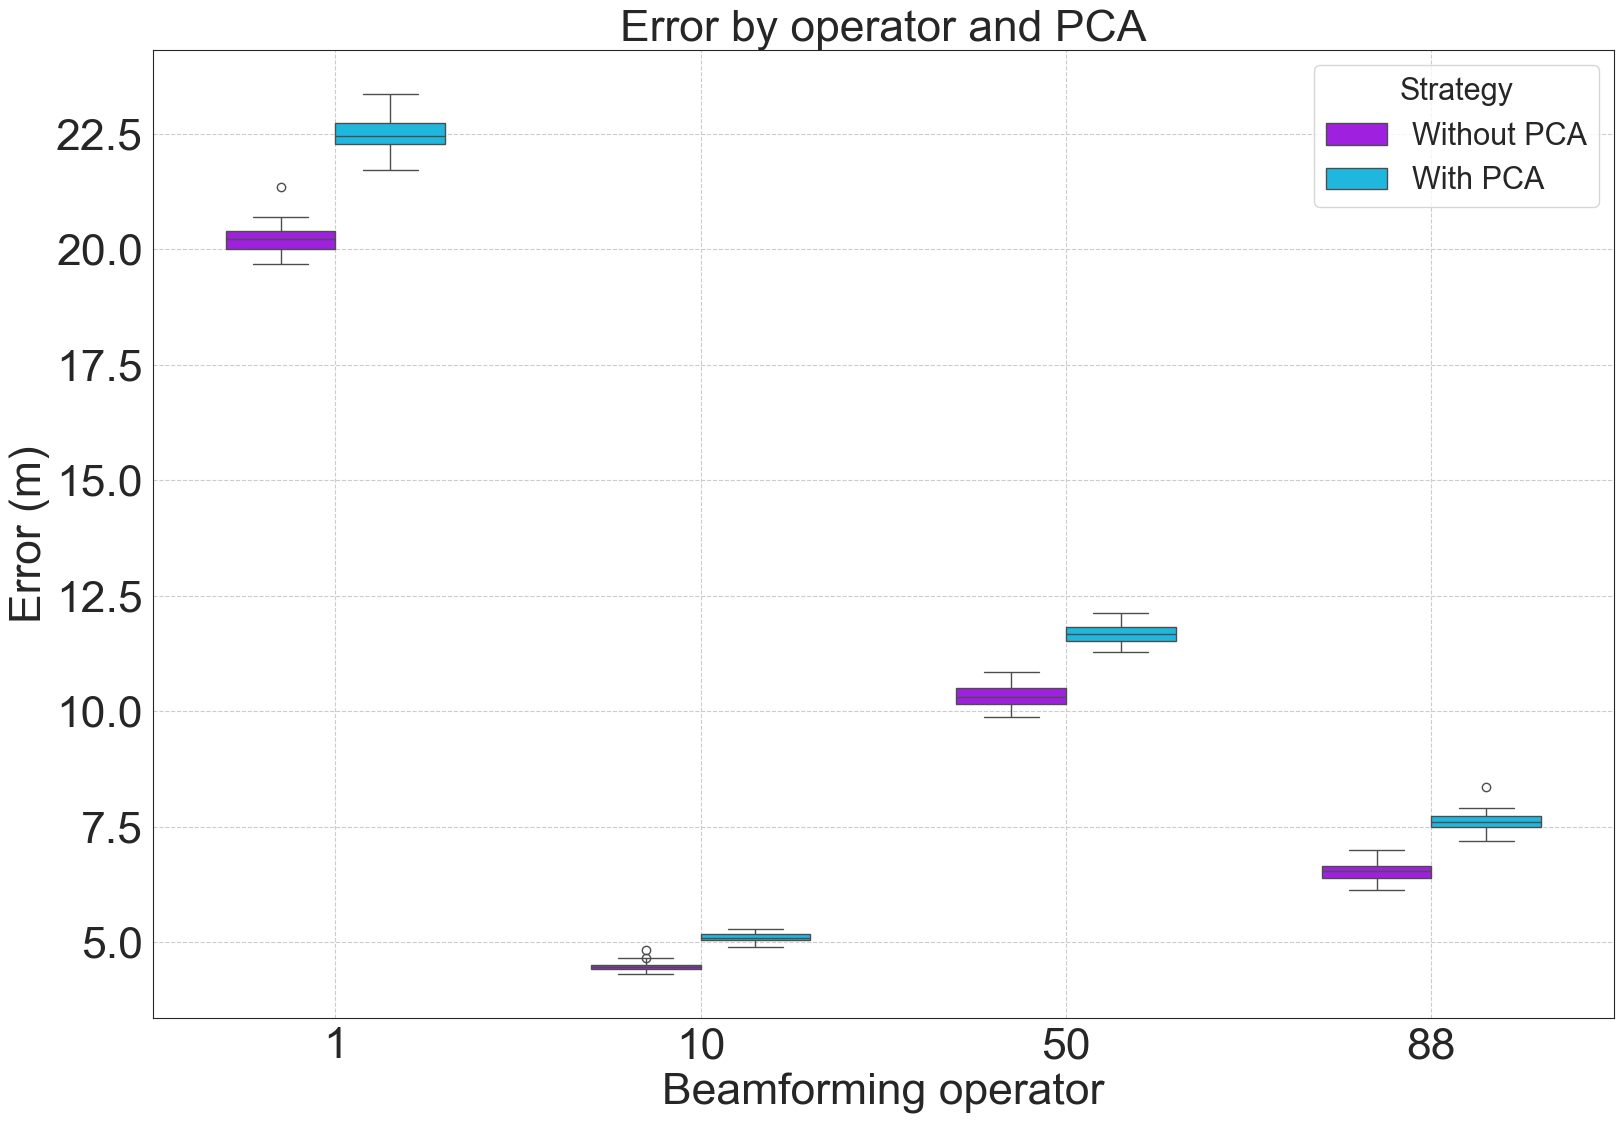

In [156]:

import seaborn as sns

palette = {'Without PCA': '#AA00FF', 'With PCA': '#00CAFF'}


def plot_pca_experiment(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.boxplot(x='operator', y='error', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment(result_df)

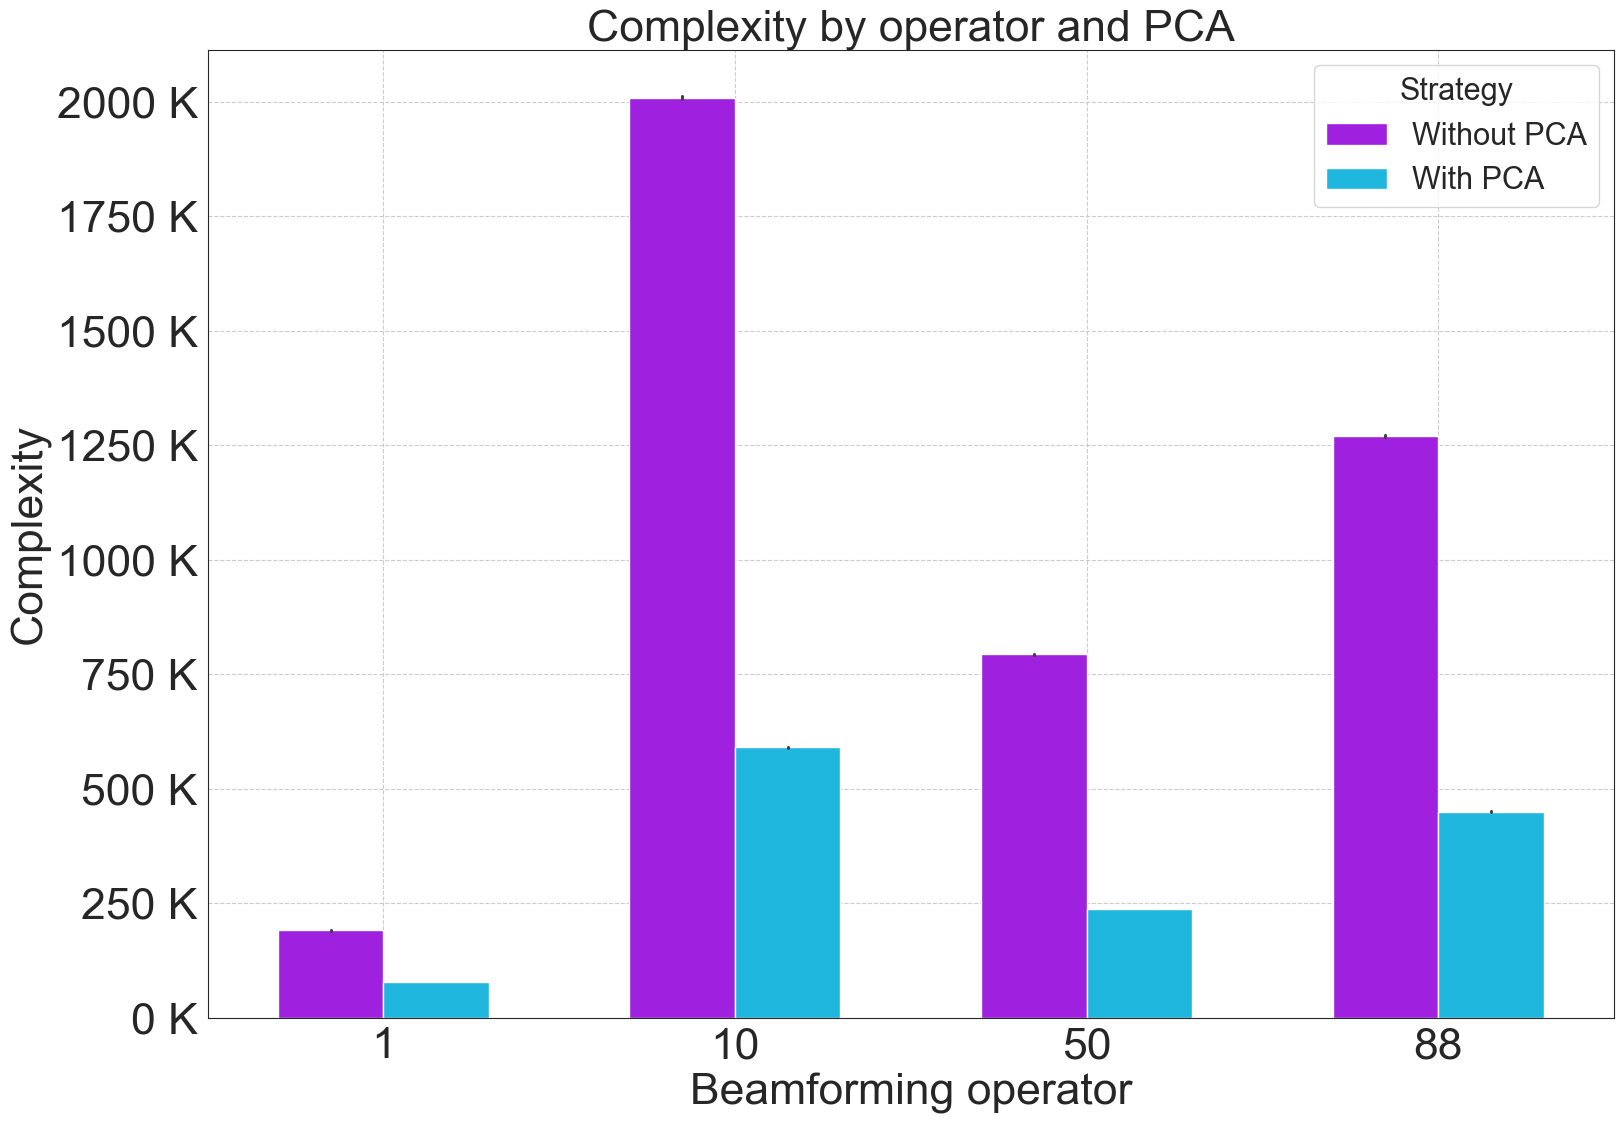

In [157]:
def plot_pca_experiment_complexity(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.barplot(x='operator', y='complexity', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Complexity')
    plt.title('Complexity by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f K'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment_complexity(result_df)